In [1]:
from __future__ import annotations
import os
import operator
from typing import TypedDict, List, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.messages import SystemMessage, HumanMessage

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=os.getenv("GEMINI_API_KEY"),
    temperature=0,
)

#print(llm.invoke("Hello"))

In [4]:
class Task(BaseModel):
    id:int
    title:str
    brief:str=Field(..., description="what to cover")

In [5]:
class Plan(BaseModel):
    blog_title:str
    tasks:List[Task]


In [6]:
class State(TypedDict):
    plan: Plan
    topic:str
    sections:Annotated[List[str],operator.add]
    final:str

In [7]:
def orchestrator(state: State)->dict:
    plan=llm.with_structured_output(Plan).invoke([
        SystemMessage(
            content=("Create a blog plan with 5-7 sections on following topic.")
        ),
        HumanMessage(
            content=f"Topic :{ state["topic"] }"
        ),
    ])
    return {"plan":plan}

In [8]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [9]:
def worker(payload: dict)->dict:
    task=payload["task"]
    topic=payload["topic"]
    plan=payload["plan"]
    blog_title=plan.blog_title
    section_md=llm.invoke([
        SystemMessage(
            content="Write one clean Markdown section."
        ),
        HumanMessage(
            content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
        ),
    ]).content.strip()
    return {"sections":[section_md]}

In [10]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [11]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

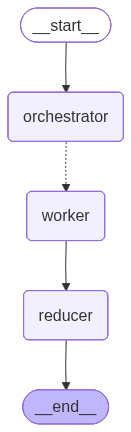

In [12]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [13]:

out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 36.191079431s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-Fre